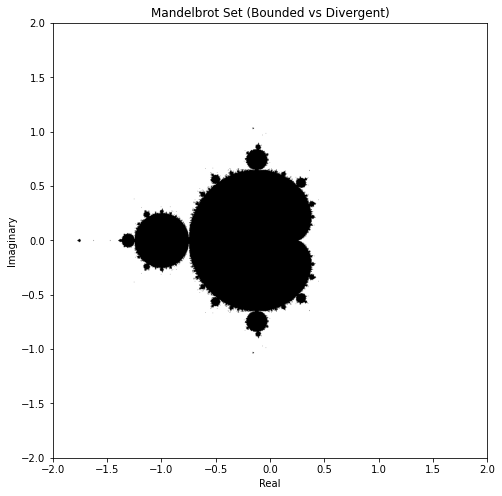

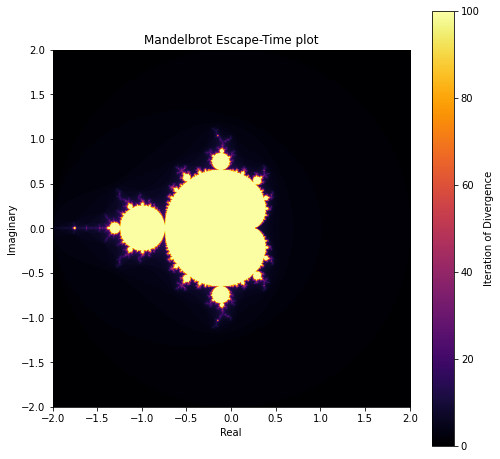

In [14]:
#question 1
import numpy as np
import matplotlib.pyplot as plt
from mandelbrot import mandelbrot
x = np.linspace(-2,2,1000)
y = np.linspace(-2,2,1000)

image = np.zeros((len(y), len(x)))

max_iter =100
for i in range(len(y)):
    for k in range(len(x)):
        c = x[k]+1j*y[i]
        image[i,k] = mandelbrot(c, max_iter)

plt.figure(figsize=(8,8))
plt.imshow(image ==max_iter, extent=[-2,2,-2,2], cmap='binary')
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title('Mandelbrot Set (Bounded vs Divergent)')
plt.savefig("Mandelbrot_bounded_divergent.pdf")
plt.show()

plt.figure(figsize=(8,8))
plt.imshow(image, extent=[-2,2,-2,2], cmap='inferno')
plt.colorbar(label='Iteration of Divergence')
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title('Mandelbrot Escape-Time plot')
plt.savefig("Mandelbrot_escape_time.pdf")
plt.show()


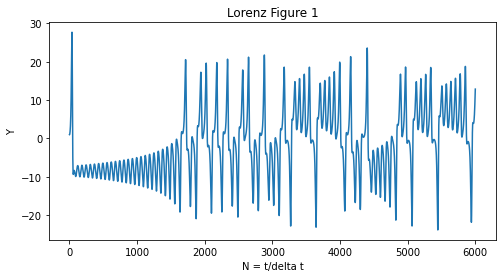

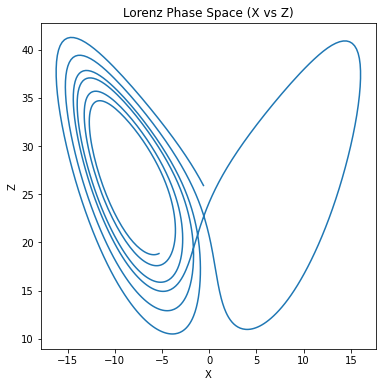

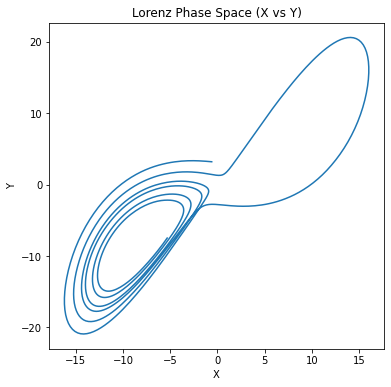

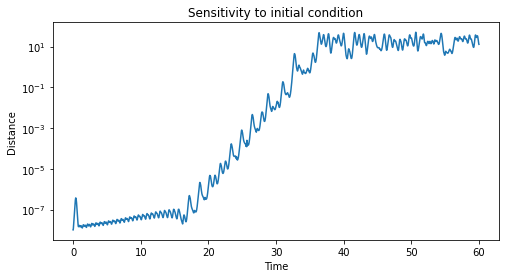

In [19]:
#question 2
#part1
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def lorenz(t,W,sigma,r,b):
    """This function is to computes the lorenz differential equations
    parameters:
    t : float, time variable
    W : list, state vector [X,Y,Z]
    sigma : float, Prandtl number.
    r : float, Rayleigh number.
    b : float, Dimensionless parameter.
    returns: list, derivatives [dX,dY,dZ]"""
    X, Y, Z = W
    dX = -sigma*(X-Y)
    dY = r*X-Y-X*Z
    dZ = -b*Z+X*Y
    return [dX, dY, dZ]

#part2
sigma = 10.
r = 28.
b = 8./3.
W0 = [0., 1., 0.]
time = (0,60)
t = np.linspace(0,60, 6000)
solution = solve_ivp(lorenz, time,W0, args = (sigma, r, b),t_eval=t )

t1 = solution.t
X = solution.y[0]
Y = solution.y[1]
Z = solution.y[2]

#part 3
N = t1/0.01
plt.figure(figsize=(8,4))
plt.plot(N,Y)
plt.xlabel("N = t/delta t")
plt.ylabel("Y")
plt.title("Lorenz Figure 1")
plt.savefig("lorenz_fig1.pdf")
plt.show()

#part4
solution2 = solve_ivp(lorenz, time, W0, args = (sigma, r,b), dense_output = True)
t_zoom = np.linspace(14,19,1000)
W_zoom = solution2.sol(t_zoom)
X_zoom = W_zoom[0]
Y_zoom = W_zoom[1]
Z_zoom = W_zoom[2]

plt.figure(figsize=(6,6))
plt.plot(X_zoom, Z_zoom)
plt.xlabel("X")
plt.ylabel("Z")
plt.title("Lorenz Phase Space (X vs Z)")
plt.savefig("lorenz_fig_xz.pdf")
plt.show()

plt.figure(figsize=(6,6))
plt.plot(X_zoom, Y_zoom)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Lorenz Phase Space (X vs Y)")
plt.savefig("lorenz_fig_xy.pdf")
plt.show()

#part5
W0_prime = [0., 1.00000001, 0.]
solution_prime = solve_ivp(lorenz,time,W0_prime, args = (sigma, r, b), t_eval = t)
X_prime = solution_prime.y[0]
Y_prime = solution_prime.y[1]
Z_prime = solution_prime.y[2]
distance = np.sqrt((X_prime -X)**2 +(Y_prime -Y)**2+(Z_prime -Z)**2)

plt.figure(figsize=(8,4))
plt.semilogy(t1, distance)
plt.xlabel("Time")
plt.ylabel("Distance")
plt.title("Sensitivity to initial condition")
plt.savefig("sensitivity_initial_condition.pdf")
plt.show()